# <center>**Hemibrain and Male-CNS Partner-Check for LC17**</center>

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# Plotting
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, PowerNorm
import matplotlib.ticker as mticker
norm = LogNorm(1, 15000)
import seaborn as sns
sns.set_style("ticks")

In [2]:
palette = {"hemibrain"      : "orange",
           "male-cns-right" : "red",
           "male-cns-left"  : "blue"}

## Weights

Outputs

In [3]:
hemi_df = pd.read_parquet("../Data/Partners/hemibrain_LC17_population-outputs.parquet", engine = "pyarrow")
male_df = pd.read_parquet("../Data/Partners/malecns_LC17_population-outputs.parquet", engine = "pyarrow")

# Take a look
male_df

,instance_pre,bodyId_post,instance_post,type_post,weight
0,LC17_L,10021,CB2049_L,CB2049,2
1,LC17_L,10100,LoVCLo3_R,LoVCLo3,37
2,LC17_L,10129,LoVC16_L,LoVC16,5725
3,LC17_L,10158,LT56_L,LT56,82
4,LC17_L,10172,AVLP080_L,AVLP080,59
...,...,...,...,...,...
820,LC17_R,539413,LT56_R,LT56,20
821,LC17_R,542002,Li25_R,Li25,8
822,LC17_R,557966,CB4168_R,CB4168,7
823,LC17_R,563537,AVLP551_R,AVLP551,85


Recurrent Inputs

In [4]:
hemi_rec_df = pd.read_parquet("../Data/Partners/hemibrain_LC17_population-inputs.parquet", engine = "pyarrow")
male_rec_df = pd.read_parquet("../Data/Partners/malecns_LC17_population-inputs.parquet", engine = "pyarrow")

# Take a look
male_rec_df

,instance_post,bodyId_pre,instance_pre,type_pre,weight
0,LC17_L,10100,LoVCLo3_R,LoVCLo3,286
1,LC17_L,10129,LoVC16_L,LoVC16,1034
2,LC17_L,10158,LT56_L,LT56,3182
3,LC17_L,10172,AVLP080_L,AVLP080,1146
4,LC17_L,10220,LoVC16_L,LoVC16,1040
...,...,...,...,...,...
577,LC17_R,522405,PVLP106_R,PVLP106,218
578,LC17_R,523624,PVLP018_L,PVLP018,1103
579,LC17_R,525496,PVLP082_R,PVLP082,11
580,LC17_R,539413,LT56_R,LT56,3632


Plotting weight distributions

/tmp/ipykernel_1749950/3320469741.py:66: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  a.set_xlim(0, 50000)


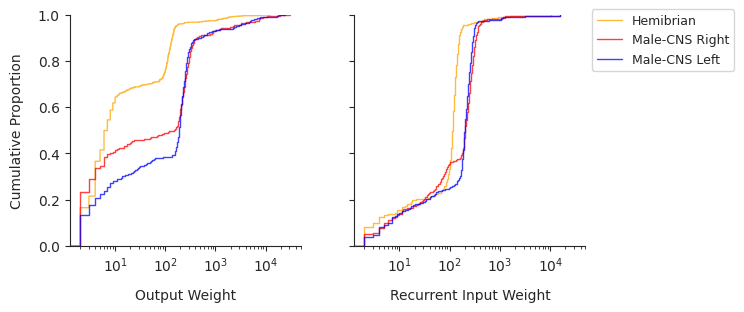

In [5]:
fig, ax = plt.subplots(figsize = (8, 3), ncols = 2, sharey = True)
plt.subplots_adjust(wspace = -0.15)
#------------------------------------------------------------------
# Outputs
# ECDFplot
sns.ecdfplot(hemi_df,
             x  = "weight",
             ax = ax[0], 
             alpha = 0.75,
             linewidth = 1,
             label = "Hemibrian",
             color = palette["hemibrain"])

# ECDFplot
sns.ecdfplot(male_df.loc[male_df["instance_pre"] == "LC17_R"],
             x  = "weight",
             ax = ax[0], 
             alpha = 0.75,
             linewidth = 1,
             label = "Male-CNS Right",
             color = palette["male-cns-right"])
             
# ECDFplot
sns.ecdfplot(male_df.loc[male_df["instance_pre"] == "LC17_L"],
             x  = "weight",
             ax = ax[0], 
             alpha = 0.75,
             linewidth = 1, 
             label = "Male-CNS Left",
             color = palette["male-cns-left"])

#------------------------------------------------------------------
# Inputs
# ECDFplot
sns.ecdfplot(hemi_rec_df,
             x  = "weight",
             ax = ax[1], 
             alpha = 0.75,
             linewidth = 1,
             label = "Hemibrian",
             color = palette["hemibrain"])

# ECDFplot
sns.ecdfplot(male_rec_df.loc[male_rec_df["instance_post"] == "LC17_R"],
             x  = "weight",
             ax = ax[1], 
             alpha = 0.75,
             linewidth = 1,
             label = "Male-CNS Right",
             color = palette["male-cns-right"])

# ECDFplot
sns.ecdfplot(male_rec_df.loc[male_rec_df["instance_post"] == "LC17_L"],
             x  = "weight",
             ax = ax[1], 
             alpha = 0.75,
             linewidth = 1, 
             label = "Male-CNS Left",
             color = palette["male-cns-left"])


# Despine
for a in ax:
    sns.despine(ax = a)
    a.set_xscale("log")
    a.set_xlim(0, 50000)
    a.set_box_aspect(1)

# Legend
ax[1].legend(
          fontsize = 9, 
          loc = "upper left",
          bbox_to_anchor = (1, 1.05))
# Labels
ax[0].set_xlabel("Output Weight", labelpad = 10)
ax[1].set_xlabel("Recurrent Input Weight", labelpad = 10)
ax[0].set_ylabel("Cumulative Proportion", labelpad = 10)

# Save
plt.savefig("../Figures/Partners/LC17_Partner-Weights.pdf", dpi = 600, bbox_inches = "tight")
plt.savefig("../Figures/Partners/LC17_Partner-Weights.png", dpi = 600, bbox_inches = "tight")

## Outputs of LC17

Subsetting with weight > 100 

In [6]:
min_weight = 100

In [7]:
def clean_partners(df, min_weight):
    """
    Just clean up and organize the df filter
    """
    # Subset
    subset = df.loc[df["weight"] > min_weight]
    # Remove interconnections to LCs and NA
    subset = subset.loc[~(subset["type_post"].str.contains("LC")) & 
                        ~(subset["type_post"] == "NA")].reset_index(drop = True)

    # Convert to matrix
    matrix = pd.crosstab(subset.instance_pre,
                         [subset.instance_post, subset.bodyId_post],
                         values = subset.weight,
                         aggfunc = "sum")

    return subset, matrix

In [8]:
hemi_subset, hemi_matrix = clean_partners(hemi_df, min_weight)
male_subset, male_matrix = clean_partners(male_df, min_weight)

Plot heatmaps!

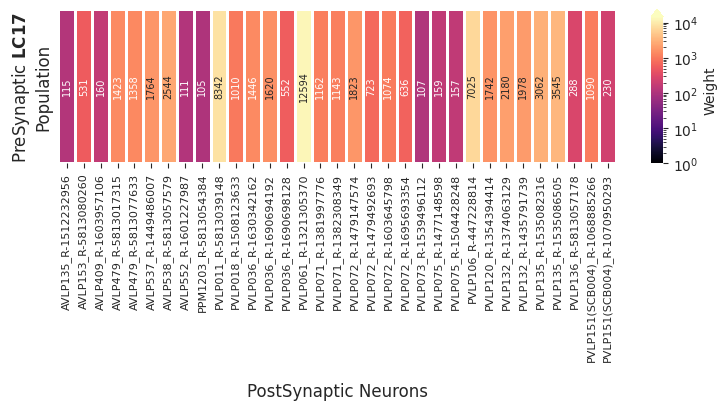

In [9]:
fig, ax = plt.subplots(figsize = (9, 2))

# Place heatmap
sns.heatmap(hemi_matrix, 
            norm       = norm,
            cmap = "magma",
            linewidths = 1,
            annot = True,
            fmt   = "d",
            annot_kws = {"rotation" : 90,
                         "size"     : 7},
            cbar_kws  = {"label"  : "Weight",
                         "shrink" : 1,
                         "aspect" : 13,
                         "extend" : "max"},
            xticklabels = True) 

# Labels
ax.set_ylabel("PreSynaptic $\mathbf{LC17}$ \nPopulation", fontsize = 12);
ax.set_xlabel("PostSynaptic Neurons", labelpad = 15, fontsize = 12);
ax.set_yticks([])

# Tick params
ax.tick_params(axis = "both", labelsize = 8)

# Save
plt.savefig(f"../Figures/Partners/hemibrain_LC17_Output-Heatmap-{min_weight}.pdf", dpi = 600, bbox_inches = "tight")
plt.savefig(f"../Figures/Partners/hemibrain_LC17_Output-Heatmap-{min_weight}.png", dpi = 600, bbox_inches = "tight")

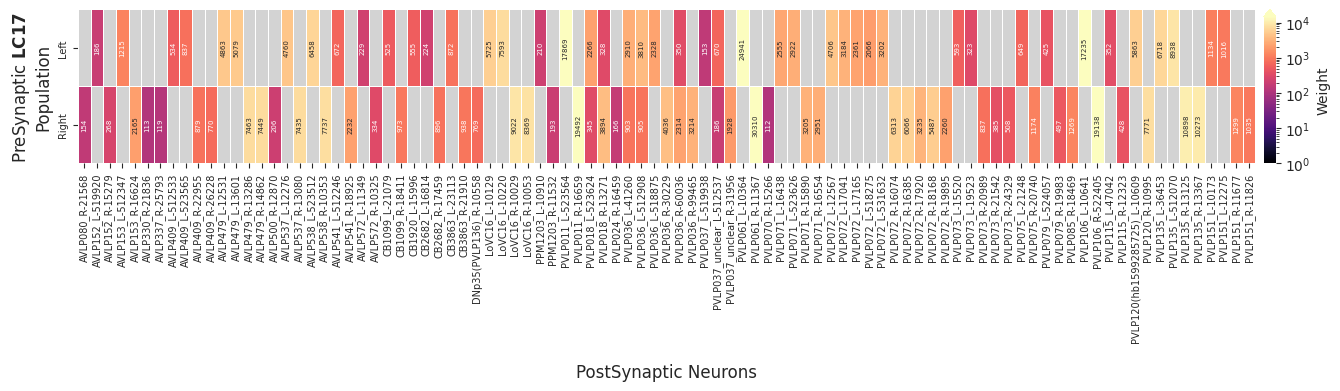

In [10]:
fig, ax = plt.subplots(figsize = (18, 2))

ax.set_facecolor("lightgrey")
# Place heatmap
sns.heatmap(male_matrix.fillna(0).astype(int), 
            norm       = norm,
            cmap = "magma",
            mask = male_matrix.fillna(0) == 0, 
            linewidths = 0.5,
            annot = True,
            fmt   = "d",
            annot_kws = {"rotation" : 90,
                         "size"     : 5},
            cbar_kws  = {"label"  : "Weight",
                         "shrink" : 1,
                         "aspect" : 13,
                         "pad"    : 0.006,
                         "extend" : "max"},
            xticklabels = True) 

# Labels
ax.set_ylabel("PreSynaptic $\mathbf{LC17}$ \nPopulation", fontsize = 12);
ax.set_xlabel("PostSynaptic Neurons", labelpad = 15, fontsize = 12);
ax.set_yticklabels(["Left", "Right"])

# Tick params
ax.tick_params(axis = "both", labelsize = 7)

# Save
plt.savefig(f"../Figures/Partners/malecns_LC17_Output-Heatmap-{min_weight}.pdf", dpi = 600, bbox_inches = "tight")
plt.savefig(f"../Figures/Partners/malecns_LC17_Output-Heatmap-{min_weight}.png", dpi = 600, bbox_inches = "tight")

### Comparing Shared Partners

In [11]:
# Types each dataset connects to
hemi_types = set(hemi_subset["type_post"])
male_types = set(male_subset["type_post"])
shared     = hemi_types & male_types

# Common view of shared and unique connections
shared_df = pd.concat(
    [hemi_subset.groupby("type_post").agg(hemibrain_weight = ("weight", "sum"),
                                          hemibrain_n      = ("bodyId_post", "nunique")),
     male_subset.groupby("type_post").agg(malecns_weight   = ("weight", "sum"),
                                          malecns_n        = ("bodyId_post", "nunique"))],
    axis = 1).fillna(0).astype(int)

# Flag where each type shows up
shared_df["status"] = np.where(shared_df.index.isin(shared), "shared",
                      np.where(shared_df.index.isin(hemi_types), "hemibrain only",
                                                                 "male-cns only"))

# Shared types first, heaviest at the top
shared_df = shared_df.sort_values(["status", "hemibrain_weight", "malecns_weight"],
                                  ascending = [True, False, False])

# Take a look
print(f"hemibrain : {len(hemi_types)} types | male-cns : {len(male_types)} types | shared : {len(shared)}")
shared_df

hemibrain : 22 types | male-cns : 38 types | shared : 18


,hemibrain_weight,hemibrain_n,malecns_weight,malecns_n,status
type_post,,,,,
PVLP132,4158,2,0,0,hemibrain only
PVLP136,288,1,0,0,hemibrain only
AVLP135,115,1,0,0,hemibrain only
AVLP552,111,1,0,0,hemibrain only
LoVC16,0,0,30709,4,male-cns only
AVLP541,0,0,2904,2,male-cns only
PVLP037_unclear,0,0,2784,2,male-cns only
CB3863,0,0,1810,2,male-cns only
CB1099,0,0,1498,2,male-cns only


In [12]:
# Treating Left and Right Separately for Male-CNS
sources = {"Hemibrain" : hemi_subset,
           "Male_R"    : male_subset.loc[male_subset["instance_pre"] == "LC17_R"],
           "Male_L"    : male_subset.loc[male_subset["instance_pre"] == "LC17_L"]}

columns = {}

for name, df in sources.items():
    weight = df.groupby("type_post")["weight"].sum()

    # Rank within that dataset's own partner list, 1 = strongest partner
    columns[f"{name}_weight"] = weight
    columns[f"{name}_rank"]   = weight.rank(ascending = False, method = "min")

    print(f"{name:10s} : {len(weight)} partner types")

compare = pd.DataFrame(columns)

# Only the types both datasets have
# Ranks stay as per the Dataset's overall true ranking based on all partners
compare = compare.loc[compare.index.isin(shared)]
compare = compare.sort_values("Hemibrain_rank")
\
# Take a look
print(f"\nshared types carried forward : {len(compare)}")
compare

Hemibrain  : 22 partner types
Male_R     : 36 partner types
Male_L     : 30 partner types

shared types carried forward : 18


,Hemibrain_weight,Hemibrain_rank,Male_R_weight,Male_R_rank,Male_L_weight,Male_L_rank
type_post,,,,,,
PVLP061,12594.0,1.0,30310.0,1.0,24941.0,1.0
PVLP011,8342.0,2.0,19492.0,4.0,17869.0,2.0
PVLP106,7025.0,3.0,19138.0,5.0,17235.0,3.0
PVLP135,6607.0,4.0,21171.0,3.0,15656.0,4.0
PVLP072,4256.0,5.0,23361.0,2.0,15519.0,5.0
PVLP036,3618.0,7.0,11372.0,8.0,9398.0,8.0
AVLP479,2781.0,8.0,14912.0,7.0,9942.0,7.0
AVLP538,2544.0,9.0,7737.0,10.0,6458.0,9.0
PVLP071,2305.0,10.0,6156.0,12.0,5477.0,11.0


Plotting Helpers

In [13]:
def scatter_panel(ax, x, y, color, label, log):
    """
    One comparison panel with its identity line and Spearman rho.
    """
    keep = x.notna() & y.notna()
    x, y = x[keep], y[keep]

    rho, pval = spearmanr(x, y)

    # Design label
    if label == "":
        lab = f"$\\rho$ = {rho:.2f}"
    else:
        lab = f"{label} ($\\rho$ = {rho:.2f})"

    ax.scatter(x, y,
               s         = 24,
               color     = color,
               alpha     = 0.75,
               linewidth = 0.4,
               edgecolor = "white",
               label     = lab,
               zorder    = 3)

    return rho, pval

def finish_panel(ax, lo, hi, log, invert):
    """
    Square the panel up, drop an identity line through it and despine.
    """
    ax.plot([lo, hi],
            [lo, hi],
            color = "grey", linestyle = "--", linewidth = 0.8,
            zorder = 1)

    if log:
        ax.set_xscale("log")
        ax.set_yscale("log")

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal")

    # For ranks, put the strongest partner at the top right like the weights
    if invert:
        ax.invert_xaxis()
        ax.invert_yaxis()
        
    sns.despine(ax = ax)
    ax.tick_params(axis = "both", labelsize = 8)
    ax.legend(fontsize = 6,
              frameon  = True,
              loc = "upper left",
              markerscale = 0.6,
              handletextpad = 0.15)

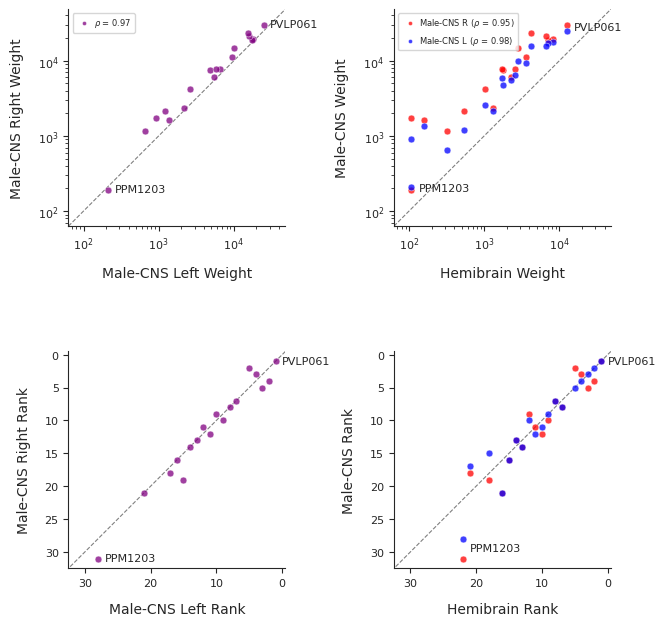

In [14]:
fig, axes = plt.subplots(2, 2, figsize = (7, 8))
plt.subplots_adjust(hspace = 0.25, wspace = 0.5)

for row, (measure, log, invert) in enumerate([("weight", True,  False),
                                              ("rank",   False, True)]):

    #-----------------------------------------------------------------------
    # Left : the two male-CNS hemispheres against each other.
    # Within-dataset noise
    left = axes[row, 0]
    scatter_panel(left,
                  compare[f"Male_L_{measure}"],
                  compare[f"Male_R_{measure}"],
                  "purple",
                  "",
                  log)

    left.set_xlabel(f"Male-CNS Left {measure.capitalize()}", labelpad = 10)
    left.set_ylabel(f"Male-CNS Right {measure.capitalize()}", labelpad = 10)

    #-----------------------------------------------------------------------
    # Right : hemibrain against each hemisphere separately
    # Across dataset offsets
    right = axes[row, 1]
    for hemisphere, key in [("male-cns-right", "Male_R"),
                            ("male-cns-left",  "Male_L")]:
        scatter_panel(right,
                      compare[f"Hemibrain_{measure}"],
                      compare[f"{key}_{measure}"],
                      palette[hemisphere],
                      f"Male-CNS {key[-1]}", log)

    right.set_xlabel(f"Hemibrain {measure.capitalize()}", labelpad = 10)
    right.set_ylabel(f"Male-CNS {measure.capitalize()}", labelpad = 10)

    # A shared range keeps the identity line meaningful across both panels
    values = compare[[c for c in compare.columns if c.endswith(measure)]]
    lo, hi = np.nanmin(values.values), np.nanmax(values.values)

    if log:
        lo, hi = lo * 0.6, hi * 1.6
    else:
        lo, hi = lo - 1.5, hi + 1.5

    # Finishing touches to panels
    finish_panel(left,  lo, hi, log, invert)
    finish_panel(right, lo, hi, log, invert)

#-----------------------------------------------------------------------
# Some fun manual labeling!
#----------------------
# Add odd offset marker
# PPM1203 has an odd offest between the two datasets - labeling it here
axes[0, 0].text(compare.iloc[-1].Male_L_weight + 50, 
                compare.iloc[-1].Male_R_weight,
                compare.iloc[-1].name,
                va = "center",
                fontsize = 8)

axes[0, 1].text(compare.iloc[-1].Hemibrain_weight + 30,
                (compare.iloc[-1].Male_R_weight + compare.iloc[-1].Male_L_weight) / 2,
                compare.iloc[-1].name,
                va = "center",
                fontsize = 8)

axes[1, 0].text(compare.iloc[-1].Male_L_rank - 1,
                compare.iloc[-1].Male_R_rank,
                compare.iloc[-1].name,
                va = "center",
                fontsize = 8)

axes[1, 1].text(compare.iloc[-1].Hemibrain_rank - 1,
                (compare.iloc[-1].Male_R_rank + compare.iloc[-1].Male_L_rank) / 2,
                compare.iloc[-1].name,
                va = "center",
                fontsize = 8)
                
#----------------------
# Top Rank PVLP061
axes[0, 0].text(compare.iloc[0].Male_L_weight + 5000,
                compare.iloc[0].Male_R_weight,
                compare.iloc[0].name,
                va = "center",
                fontsize = 8)

axes[0, 1].text(compare.iloc[0].Hemibrain_weight + 3000,
                (compare.iloc[0].Male_R_weight + compare.iloc[0].Male_L_weight) / 2,
                compare.iloc[0].name,
                va = "center",
                fontsize = 8)

axes[1, 0].text(compare.iloc[0].Male_L_rank - 1,
                compare.iloc[0].Male_R_rank,
                compare.iloc[0].name,
                va = "center",
                fontsize = 8)

axes[1, 1].text(compare.iloc[0].Hemibrain_rank - 1,
                (compare.iloc[0].Male_R_rank + compare.iloc[0].Male_L_rank) / 2,
                compare.iloc[0].name,
                va = "center",
                fontsize = 8)

# Remove correlation labels at the bottom
for a in axes[1, :]:
    a.legend().set_visible(False)

#-----------------------------------------------------------------------
# Save
plt.savefig(f"../Figures/Partners/LC17_Weight-Rank-Comparison-Output-{min_weight}.pdf",
            dpi = 600,
            bbox_inches = "tight")
plt.savefig(f"../Figures/Partners/LC17_Weight-Rank-Comparison-Output-{min_weight}.png",
            dpi = 600,
            bbox_inches = "tight")

## Recurrent Inputs of LC17

We only want to measure for the shared neuron types across the datasets.

In [15]:
def rec_shared(df, shared_list = list(shared)):
    """
    Getting the shared recurrently connected things
    """
    # Get the shared
    shared_rec = df.loc[df["type_pre"].isin(shared_list)]

    # Convert to matrix 
    matrix = pd.crosstab([shared_rec.instance_pre, shared_rec.bodyId_pre],
                         shared_rec.instance_post,
                         values = shared_rec.weight,
                         aggfunc = "sum").fillna(0).astype(int)

    return shared_rec, matrix

# Both datasets
hemi_rec_shared, hemi_rec_matrix = rec_shared(hemi_rec_df)
male_rec_shared, male_rec_matrix = rec_shared(male_rec_df)

# Take a look
hemi_rec_matrix

instance_post                 LC17_R
instance_pre      bodyId_pre        
AVLP153_R         5813080260       2
AVLP479_R         5813017315      43
AVLP537_R         1449486007      17
AVLP538_R         5813057579     259
PPM1203_R         5813054384     428
PVLP011_R         5813039148   10370
PVLP018_R         1508123633     123
PVLP036_R         1630342162     115
                  1690694192     110
                  1690698128       4
PVLP061_R         1321305370     230
PVLP072_R         1479147574      17
PVLP106_R         447228814      299
PVLP135_R         1535086505       2
PVLP151(SCB004)_R 1068885266    1075

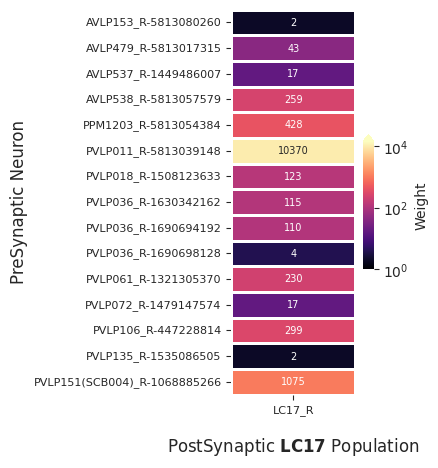

In [16]:
fig, ax = plt.subplots(figsize = (2, 5))

# Place heatmap
sns.heatmap(hemi_rec_matrix, 
            norm       = norm,
            cmap = "magma",
            linewidths = 1,
            annot = True,
            fmt   = "d",
            annot_kws = {"rotation" : 0,
                         "size"     : 7},
            cbar_kws  = {"label"  : "Weight",
                         "shrink" : 0.35,
                         "aspect" : 13,
                         "extend" : "max"},
            xticklabels = True) 

# Labels
ax.set_ylabel("PreSynaptic Neuron", fontsize = 12);
ax.set_xlabel("PostSynaptic $\mathbf{LC17}$ Population", labelpad = 15, fontsize = 12);
# ax.set_yticks([])

# Tick params
ax.tick_params(axis = "both", labelsize = 8)

# Save
plt.savefig(f"../Figures/Partners/hemibrain_LC17_Input-Shared-Heatmap-{min_weight}.pdf",
            dpi = 600,
            bbox_inches = "tight")
plt.savefig(f"../Figures/Partners/hemibrain_LC17_Input-Shared-Heatmap-{min_weight}.png",
            dpi = 600,
            bbox_inches = "tight")

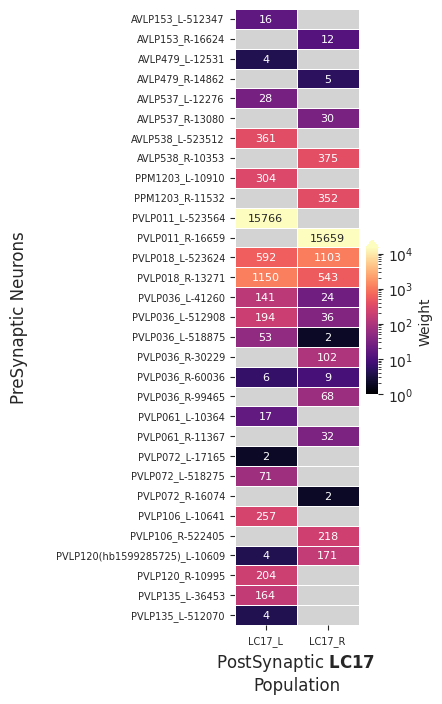

In [17]:
fig, ax = plt.subplots(figsize = (2, 8))

ax.set_facecolor("lightgrey")
# Place heatmap
sns.heatmap(male_rec_matrix, 
            norm       = norm,
            cmap = "magma",
            mask = male_rec_matrix == 0, 
            linewidths = 0.5,
            annot = True,
            fmt   = "d",
            annot_kws = {"rotation" : 0,
                         "size"     : 8},
            cbar_kws  = {"label"  : "Weight",
                         "shrink" : 0.25,
                         "aspect" : 13,
                         "extend" : "max"},
            xticklabels = True) 

# Labels
ax.set_xlabel("PostSynaptic $\mathbf{LC17}$ \nPopulation", fontsize = 12);
ax.set_ylabel("PreSynaptic Neurons", labelpad = 20, fontsize = 12);
# ax.set_yticklabels(["Left", "Right"])

# Tick params
ax.tick_params(axis = "both", labelsize = 7)

# Save
plt.savefig(f"../Figures/Partners/malecns_LC17_Input-Shared-Heatmap-{min_weight}.pdf",
            dpi = 600,
            bbox_inches = "tight")
plt.savefig(f"../Figures/Partners/malecns_LC17_Input-Shared-Heatmap-{min_weight}.png",
            dpi = 600,
            bbox_inches = "tight")

### Recurrent vs Feedforward Partners

Output weight against recurrent input weight, for the shared types. 

Partners climbing towards the identity line are reciprocally coupled to LC17.

Partners pinned to the bottom axis are purely feedforward targets.

**Note** : The connection is condensed by neuron type. So we ignore the hemisphere identity completely for the post synaptic partner.

In [18]:
# Splitting the Recurrent Inputs the same way
rec_sources = {"Hemibrain" : hemi_rec_df,
               "Male_R"    : male_rec_df.loc[male_rec_df["instance_post"] == "LC17_R"],
               "Male_L"    : male_rec_df.loc[male_rec_df["instance_post"] == "LC17_L"]}

for name, df in rec_sources.items():
    feedback = df.groupby("type_pre")["weight"].sum()

    # Nothing coming back is a real zero here, not a missing value
    compare[f"{name}_input"] = feedback.reindex(compare.index).fillna(0)

    # Fraction of the traffic with LC17 that runs backwards
    total = compare[f"{name}_input"] + compare[f"{name}_weight"]
    compare[f"{name}_reciprocity"] = compare[f"{name}_input"] / total

    silent = (compare[f"{name}_input"] == 0).sum()
    print(f"{name:10s} : {silent} of {len(compare)} types send nothing back")

# Just the weights and the inputs
weights = [c for c in compare.columns
           if c.endswith("_weight") or c.endswith("_input")]

# Save the partners
compare.to_parquet("../Data/Partners/LC17_dataset-shared-partners.parquet",
                  engine = "pyarrow")

Hemibrain  : 5 of 18 types send nothing back
Male_R     : 6 of 18 types send nothing back
Male_L     : 5 of 18 types send nothing back


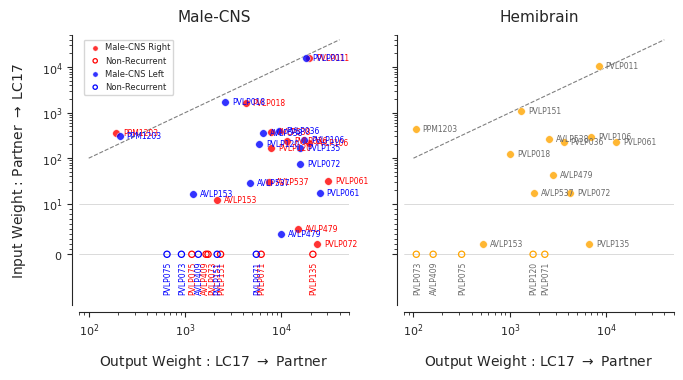

In [19]:
# Zeros can't sit on a log axis, so the y axis goes symlog
# Anything sitting on the floor is drawn hollow - nothing comes back
linthresh = 10

fig, ax = plt.subplots(figsize = (8, 3.5), ncols = 2, sharex = True, sharey = True)
plt.subplots_adjust(wspace = 0.1)

# Partners that send nothing back
male_R_quiet = compare["Male_R_input"]    == 0
male_L_quiet = compare["Male_L_input"]    == 0
hemi_quiet   = compare["Hemibrain_input"] == 0

#------------------------------------------------------------------
# Male-CNS
# Right
ax[0].scatter(compare["Male_R_weight"].loc[~male_R_quiet],
              compare["Male_R_input"].loc[~male_R_quiet],
              s = 30,
              alpha = 0.8,
              linewidth = 0.4,
              edgecolor = "white",
              label = "Male-CNS Right",
              color = palette["male-cns-right"],
              zorder = 3)

# Right - nothing back
ax[0].scatter(compare["Male_R_weight"].loc[male_R_quiet],
              compare["Male_R_input"].loc[male_R_quiet],
              s = 20,
              linewidth = 0.9,
              facecolor = "none",
              label = "Non-Recurrent",
              edgecolor = palette["male-cns-right"],
              zorder = 3)

# Left
ax[0].scatter(compare["Male_L_weight"].loc[~male_L_quiet],
              compare["Male_L_input"].loc[~male_L_quiet],
              s = 30,
              alpha = 0.8,
              linewidth = 0.4,
              edgecolor = "white",
              label = "Male-CNS Left",
              color = palette["male-cns-left"],
              zorder = 3)

# Left - nothing back
ax[0].scatter(compare["Male_L_weight"].loc[male_L_quiet],
              compare["Male_L_input"].loc[male_L_quiet],
              s = 20,
              linewidth = 0.9,
              facecolor = "none",
              label = "Non-Recurrent",
              edgecolor = palette["male-cns-left"],
              zorder = 3)

#------------------------------------------------------------------
# Hemibrain
ax[1].scatter(compare["Hemibrain_weight"].loc[~hemi_quiet],
              compare["Hemibrain_input"].loc[~hemi_quiet],
              s = 30,
              alpha = 0.8,
              linewidth = 0.4,
              edgecolor = "white",
              color = palette["hemibrain"],
              zorder = 3)

# Nothing back
ax[1].scatter(compare["Hemibrain_weight"].loc[hemi_quiet],
              compare["Hemibrain_input"].loc[hemi_quiet],
              s = 20,
              linewidth = 0.9,
              facecolor = "none",
              edgecolor = palette["hemibrain"],
              zorder = 3)

#------------------------------------------------------------------
# Despine
for a in ax:
    # Reciprocity reads off position against the identity line
    a.plot([1e2, 4e4],
           [1e2, 4e4],
           color = "grey", linestyle = "--", linewidth = 0.8,
           zorder = 1)

    # Where the axis stops being logarithmic
    a.axhline(linthresh, color = "grey", linewidth = 0.5, alpha = 0.4)
    # Zero
    a.axhline(0, color = "grey", linewidth = 0.5, alpha = 0.4)

    # Adjust
    sns.despine(ax = a, offset = 5)
    a.set_xscale("log")
    a.set_yscale("symlog", linthresh = linthresh)
    a.set_xlim(80, 5e4)
    a.set_ylim(-10, 5e4)
    a.set_box_aspect(1)
    a.tick_params(axis = "both", labelsize = 8)

# Legend
ax[0].legend(fontsize = 6,
            loc = "upper left",
            markerscale = 0.7,
            handletextpad = 0.15)

#------------------------------------------------------------------
# Some fun manual labeling!
# Few enough types to name them all - the male panel goes off the right
for key, a in [("Male_R", ax[0]), ("Male_L", ax[0]), ("Hemibrain", ax[1])]:
# for key, a in [("Male_R", ax[0]), ("Hemibrain", ax[1])]:
    # Color choice
    if key == "Male_R":
        color = "red"
    elif key == "Male_L":
        color = "blue"
    else:
        color = "dimgrey"

    for name, row in compare.iterrows():
        # The quiet ones all pile onto zero, so stand their labels up
        if row[f"{key}_input"] == 0:
            rotation, offset, va = 90, (-2.5, -5), "top"
        else:
            rotation, offset, va = 0, (5, 0), "center"

        # Manually moving the overlapping ones
        if key == "Male_R":
          if name == "AVLP409":
            offset = (-4, -5)
          elif name == "PVLP073":
            offset = (0, -5)
            
        a.annotate(name,
                   (row[f"{key}_weight"], row[f"{key}_input"]),
                   xytext = offset,
                   rotation = rotation,
                   textcoords = "offset points",
                   va = va,
                   fontsize = 5.5,
                   color = color,
                   zorder = 4)

#------------------------------------------------------------------
# Yticks for y axis
major = [0, 10, 100, 1000, 10000]
minor = list(range(1, 10))
for decade in major[1:]:
  minor += [n * decade for n in range(2, 10)]

ax[0].yaxis.set_major_locator(mticker.FixedLocator(major))
ax[0].yaxis.set_minor_locator(mticker.FixedLocator(minor))

#------------------------------------------------------------------
# Titles
ax[0].set_title("Male-CNS", fontsize = 11, pad = 10)
ax[1].set_title("Hemibrain", fontsize = 11, pad = 10)

# Labels
ax[0].set_xlabel("Output Weight : LC17 $\\rightarrow$ Partner", labelpad = 10)
ax[1].set_xlabel("Output Weight : LC17 $\\rightarrow$ Partner", labelpad = 10)
ax[0].set_ylabel("Input Weight : Partner $\\rightarrow$ LC17", labelpad = 10)

# Save
plt.savefig(f"../Figures/Partners/LC17_Output-vs-Input-{min_weight}.pdf",
            dpi = 600,
            bbox_inches = "tight")
plt.savefig(f"../Figures/Partners/LC17_Output-vs-Input-{min_weight}.png",
            dpi = 600,
            bbox_inches = "tight")

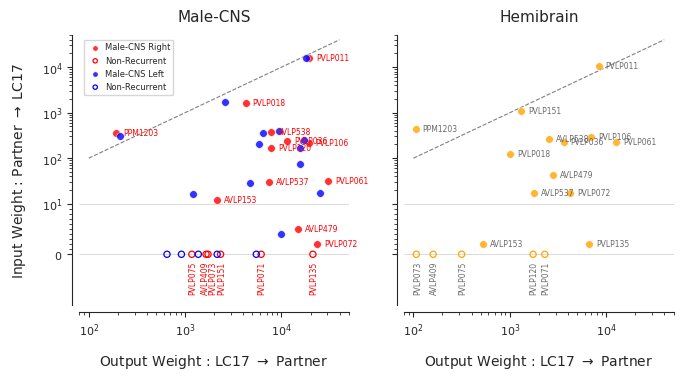

In [20]:
# Zeros can't sit on a log axis, so the y axis goes symlog
# Anything sitting on the floor is drawn hollow - nothing comes back
linthresh = 10

fig, ax = plt.subplots(figsize = (8, 3.5), ncols = 2, sharex = True, sharey = True)
plt.subplots_adjust(wspace = 0.1)

# Partners that send nothing back
male_R_quiet = compare["Male_R_input"]    == 0
male_L_quiet = compare["Male_L_input"]    == 0
hemi_quiet   = compare["Hemibrain_input"] == 0

#------------------------------------------------------------------
# Male-CNS
# Right
ax[0].scatter(compare["Male_R_weight"].loc[~male_R_quiet],
              compare["Male_R_input"].loc[~male_R_quiet],
              s = 30,
              alpha = 0.8,
              linewidth = 0.4,
              edgecolor = "white",
              label = "Male-CNS Right",
              color = palette["male-cns-right"],
              zorder = 3)

# Right - nothing back
ax[0].scatter(compare["Male_R_weight"].loc[male_R_quiet],
              compare["Male_R_input"].loc[male_R_quiet],
              s = 20,
              linewidth = 0.9,
              facecolor = "none",
              label = "Non-Recurrent",
              edgecolor = palette["male-cns-right"],
              zorder = 3)

# Left
ax[0].scatter(compare["Male_L_weight"].loc[~male_L_quiet],
              compare["Male_L_input"].loc[~male_L_quiet],
              s = 30,
              alpha = 0.8,
              linewidth = 0.4,
              edgecolor = "white",
              label = "Male-CNS Left",
              color = palette["male-cns-left"],
              zorder = 3)

# Left - nothing back
ax[0].scatter(compare["Male_L_weight"].loc[male_L_quiet],
              compare["Male_L_input"].loc[male_L_quiet],
              s = 20,
              linewidth = 0.9,
              facecolor = "none",
              label = "Non-Recurrent",
              edgecolor = palette["male-cns-left"],
              zorder = 3)

#------------------------------------------------------------------
# Hemibrain
ax[1].scatter(compare["Hemibrain_weight"].loc[~hemi_quiet],
              compare["Hemibrain_input"].loc[~hemi_quiet],
              s = 30,
              alpha = 0.8,
              linewidth = 0.4,
              edgecolor = "white",
              color = palette["hemibrain"],
              zorder = 3)

# Nothing back
ax[1].scatter(compare["Hemibrain_weight"].loc[hemi_quiet],
              compare["Hemibrain_input"].loc[hemi_quiet],
              s = 20,
              linewidth = 0.9,
              facecolor = "none",
              edgecolor = palette["hemibrain"],
              zorder = 3)

#------------------------------------------------------------------
# Despine
for a in ax:
    # Reciprocity reads off position against the identity line
    a.plot([1e2, 4e4],
           [1e2, 4e4],
           color = "grey", linestyle = "--", linewidth = 0.8,
           zorder = 1)

    # Where the axis stops being logarithmic
    a.axhline(linthresh, color = "grey", linewidth = 0.5, alpha = 0.4)
    # Zero
    a.axhline(0, color = "grey", linewidth = 0.5, alpha = 0.4)

    # Adjust
    sns.despine(ax = a, offset = 5)
    a.set_xscale("log")
    a.set_yscale("symlog", linthresh = linthresh)
    a.set_xlim(80, 5e4)
    a.set_ylim(-10, 5e4)
    a.set_box_aspect(1)
    a.tick_params(axis = "both", labelsize = 8)

# Legend
ax[0].legend(fontsize = 6,
            loc = "upper left",
            markerscale = 0.7,
            handletextpad = 0.15)

#------------------------------------------------------------------
# Some fun manual labeling!
# Few enough types to name them all - the male panel goes off the right
# for key, a in [("Male_R", ax[0]), ("Male_L", ax[0]), ("Hemibrain", ax[1])]:
for key, a in [("Male_R", ax[0]), ("Hemibrain", ax[1])]:
    # Color choice
    if key == "Male_R":
        color = "red"
    elif key == "Male_L":
        color = "blue"
    else:
        color = "dimgrey"

    for name, row in compare.iterrows():
        # The quiet ones all pile onto zero, so stand their labels up
        if row[f"{key}_input"] == 0:
            rotation, offset, va = 90, (-2.5, -5), "top"
        else:
            rotation, offset, va = 0, (5, 0), "center"

        # Manually moving the overlapping ones
        if key == "Male_R":
          if name == "AVLP409":
            offset = (-4, -5)
          elif name == "PVLP073":
            offset = (0, -5)
            
        a.annotate(name,
                   (row[f"{key}_weight"], row[f"{key}_input"]),
                   xytext = offset,
                   rotation = rotation,
                   textcoords = "offset points",
                   va = va,
                   fontsize = 5.5,
                   color = color,
                   zorder = 4)

#------------------------------------------------------------------
# Yticks for y axis
major = [0, 10, 100, 1000, 10000]
minor = list(range(1, 10))
for decade in major[1:]:
  minor += [n * decade for n in range(2, 10)]

ax[0].yaxis.set_major_locator(mticker.FixedLocator(major))
ax[0].yaxis.set_minor_locator(mticker.FixedLocator(minor))

#------------------------------------------------------------------
# Titles
ax[0].set_title("Male-CNS", fontsize = 11, pad = 10)
ax[1].set_title("Hemibrain", fontsize = 11, pad = 10)

# Labels
ax[0].set_xlabel("Output Weight : LC17 $\\rightarrow$ Partner", labelpad = 10)
ax[1].set_xlabel("Output Weight : LC17 $\\rightarrow$ Partner", labelpad = 10)
ax[0].set_ylabel("Input Weight : Partner $\\rightarrow$ LC17", labelpad = 10)

# Save
plt.savefig(f"../Figures/Partners/LC17_Output-vs-Input-{min_weight}-right-label.pdf",
            dpi = 600,
            bbox_inches = "tight")
plt.savefig(f"../Figures/Partners/LC17_Output-vs-Input-{min_weight}-right-label.png",
            dpi = 600,
            bbox_inches = "tight")

# <center>**हो गया दोस्तों**</center>